# Running Palace Simulations

[Palace](https://awslabs.github.io/palace/) is an open-source 3D electromagnetic simulator supporting eigenmode, driven (S-parameter), and electrostatic simulations. This notebook demonstrates using the `gsim.palace` API to run a driven simulation on an integrated RF transformer, extracting the broadband S-parameters to evaluate differential performance metrics such as insertion loss and impedance matching.

**Requirements:**
- IHP PDK: `uv pip install ihp-gdsfactory`
- gsim with Palace backend

In [1]:
import gdsfactory as gf
from gdsfactory import Component
from gdsfactory.typings import LayerSpec, LayerSpecs
from ihp import PDK

PDK.activate()

### Build transformer + guardring

In [2]:
@gf.cell
def transformer_stacked(
    width_primary: float = 5.0,
    width_secondary: float = 4.5,
    space: float = 3.1,
    diameter: float = 60.0,
    turns: int = 1,
    layer_primary: LayerSpec = "TopMetal2drawing",
    layer_secondary: LayerSpec = "TopMetal1drawing",
    layer_inductor: LayerSpec = "INDdrawing",
    layers_no_fill: LayerSpecs = ("NoMetFillerdrawing",),
) -> Component:
    """Stacked 1:1 transformer optimized for millimeter-wave frequencies.

    Two spiral inductors stacked vertically. The secondary coil is placed
    on a lower metal layer.

    The secondary is rotated 180° — standard convention for stacked transformers:
    places secondary ports on the opposite side from primary ports, which
    simplifies differential routing and avoids crossing metal layers.

    Args:
        width_primary: Track width of the top coil in micrometers.
        width_secondary: Track width of the bottom coil in micrometers.
        space: Spacing between turns in micrometers.
        diameter: Outer spiral diameter in micrometers.
        turns: Number of turns per coil.
        layer_primary: Metal layer for the primary coil.
        layer_secondary: Metal layer for the secondary coil.
        layer_inductor: IND marker layer (used by the PDK).
        layers_no_fill: Layers excluded from metal fill.

    Returns:
        Component with 4 coil ports:
          P1, P2  -> primary   (layer_primary)
          S1, S2  -> secondary (layer_secondary)
    """
    c = gf.Component()

    # -- Primary coil --
    primary = gf.components.inductor(
        width=width_primary,
        space=space,
        diameter=diameter,
        turns=turns,
        layer_metal=layer_primary,
        layer_inductor=layer_inductor,
        layer_metal_pin=layer_primary,
        layers_no_fill=layers_no_fill,
    )
    prim_ref = c.add_ref(primary)

    # Center primary at origin
    cx, cy = prim_ref.center
    prim_ref.move((-cx, -cy))

    # -- Secondary coil --
    secondary = gf.components.inductor(
        width=width_secondary,
        space=space,
        diameter=diameter,
        turns=turns,
        layer_metal=layer_secondary,
        layer_inductor=layer_inductor,
        layer_metal_pin=layer_secondary,
        layers_no_fill=layers_no_fill,
    )
    sec_ref = c.add_ref(secondary)
    sec_ref.rotate(180)

    # Center secondary at origin (same center as primary)
    cx, cy = sec_ref.center
    sec_ref.move((-cx, -cy))

    # -- Expose coil ports --
    c.add_port(name="P1", port=prim_ref.ports["P1"])
    c.add_port(name="P2", port=prim_ref.ports["P2"])
    c.add_port(name="S1", port=sec_ref.ports["P1"])
    c.add_port(name="S2", port=sec_ref.ports["P2"])

    return c

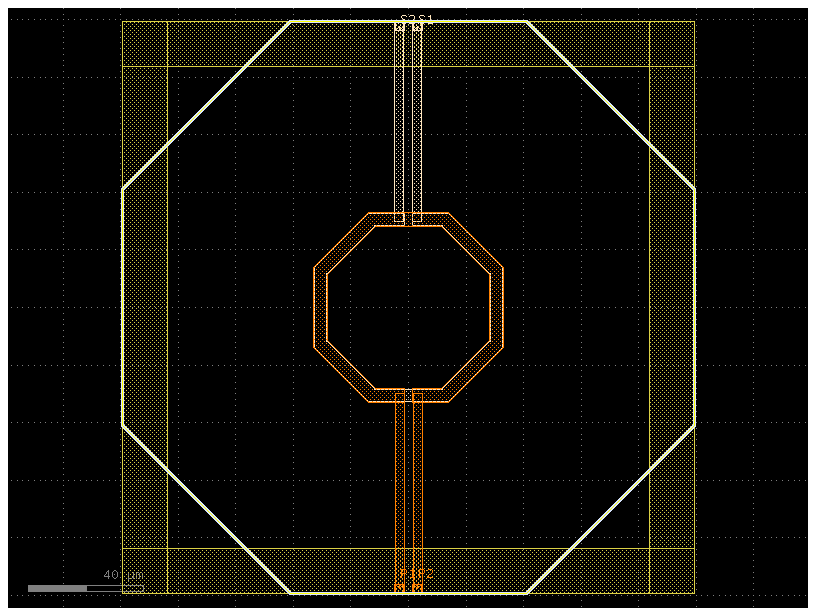

In [3]:
c = transformer_stacked().copy()

layer_guard_ring = "Metal5drawing"
guard_ring_margin = 15.0  # µm  distance from coil bbox to ring inner edge
guard_ring_overlap = 0.5  # µm  corner overlap so Gmsh fuses the pieces

bbox = c.bbox()
xmin, ymin = bbox.left, bbox.bottom
xmax, ymax = bbox.right, bbox.top

margin_outer = 0.0  # outer edge of ring flush with the coil bbox
margin_inner = -guard_ring_margin  # (negative) inner edge is INSIDE the bbox, so the ring walls sit tightly around the coil outline.

xlo, xro = xmin - margin_outer, xmax + margin_outer
ybo, yto = ymin - margin_outer, ymax + margin_outer
xli, xri = xmin - margin_inner, xmax + margin_inner
ybi, yti = ymin - margin_inner, ymax + margin_inner

w_v = xli - xlo  # width of vertical walls
h_h = yto - yti  # height of horizontal walls
ov = guard_ring_overlap  # corner overlap so Gmsh fuses the pieces

# Left wall
c.add_ref(
    gf.components.rectangle(
        size=(w_v + ov, yto - ybo),
        layer=layer_guard_ring,
        centered=True,
    )
).move((xlo + w_v / 2 + ov / 2, (yto + ybo) / 2))

# Right wall
c.add_ref(
    gf.components.rectangle(
        size=(w_v + ov, yto - ybo),
        layer=layer_guard_ring,
        centered=True,
    )
).move((xro - w_v / 2 - ov / 2, (yto + ybo) / 2))

# Top wall (spans full width including corners)
c.add_ref(
    gf.components.rectangle(
        size=(xro - xlo, h_h + ov),
        layer=layer_guard_ring,
        centered=True,
    )
).move(((xro + xlo) / 2, yto - h_h / 2 - ov / 2))

# Bottom wall
c.add_ref(
    gf.components.rectangle(
        size=(xro - xlo, h_h + ov),
        layer=layer_guard_ring,
        centered=True,
    )
).move(((xro + xlo) / 2, ybo + h_h / 2 + ov / 2))

cc = c.copy()

c.draw_ports()
c.plot()

### Configure and run simulation with DrivenSim

In [4]:
from gsim.palace import DrivenSim

# Create simulation object
sim = DrivenSim()

# Set output directory
sim.set_output_dir("./palace-sim-transformer")

# Set the component geometry
sim.set_geometry(cc)

# Configure layer stack from active PDK
sim.set_stack(substrate_thickness=180.0, include_substrate=True)

# Configure ports
sim.add_port(
    "P1", from_layer="metal5", to_layer="topmetal2", geometry="via", excited=True
)
sim.add_port(
    "P2", from_layer="metal5", to_layer="topmetal2", geometry="via", excited=True
)
sim.add_port(
    "S1", from_layer="metal5", to_layer="topmetal1", geometry="via", excited=True
)
sim.add_port(
    "S2", from_layer="metal5", to_layer="topmetal1", geometry="via", excited=True
)

# Configure driven simulation (frequency sweep for S-parameters)
sim.set_driven(fmin=10e9, fmax=200e9, num_points=50)

# Validate configuration
print(sim.validate_config())

Validation: PASSED


In [5]:
# Generate mesh (presets: "coarse", "default", "fine")
sim.set_airbox(margin_x=50, margin_y=50, z_above=50, z_below=5)
sim.mesh(preset="default", refined_mesh_size=1.5)
sim.write_config()

Info    : Reading 'palace-sim-transformer/palace.msh'...
Info    : 36716 nodes
Info    : 263757 elements
Info    : Done reading 'palace-sim-transformer/palace.msh'                                                       
Info    : Reading 'palace-sim-transformer/palace.msh'...
Info    : 36716 nodes
Info    : 263757 elements
Info    : Done reading 'palace-sim-transformer/palace.msh'                                                       
Info    : Reading 'palace-sim-transformer/palace.msh'...
Info    : 36716 nodes
Info    : 263757 elements
Info    : Done reading 'palace-sim-transformer/palace.msh'                                                       
Info    : Reading 'palace-sim-transformer/palace.msh'...
Info    : 36716 nodes
Info    : 263757 elements
Info    : Done reading 'palace-sim-transformer/palace.msh'                                                       


PosixPath('palace-sim-transformer/config.json')

In [6]:
sim.plot_mesh(show_groups=["metal", "P"])

Widget(value='<iframe src="http://localhost:42671/index.html?ui=P_0x70aefedbca40_0&reconnect=auto" class="pyvi…

In [7]:
sim.plot_mesh(
    style="solid",
    transparent_groups=["air__None", "sio2__None", "air__sio2"],
)

Widget(value='<iframe src="http://localhost:42671/index.html?ui=P_0x70aefed24fe0_1&reconnect=auto" class="pyvi…

### Run simulation on cloud

In [9]:
# Run simulation on GDSFactory+ cloud
results = sim.run(parent_dir="./palace-sim-transformer")
# results = sim.run_local(use_apptainer=False,palace_executable="~/palace/build/bin/palace",num_processes=14)

  palace-5429f371  completed  14m 06s
Extracting results.tar.gz...
Downloaded 11 files to palace-sim-transformer/sim-data-palace-5429f371


In [10]:
results.plot_interactive()

Port mapping: Port 1: P1, Port 2: P2, Port 3: S1, Port 4: S2


In [11]:
results.plot_interactive(phase=True)

Port mapping: Port 1: P1, Port 2: P2, Port 3: S1, Port 4: S2


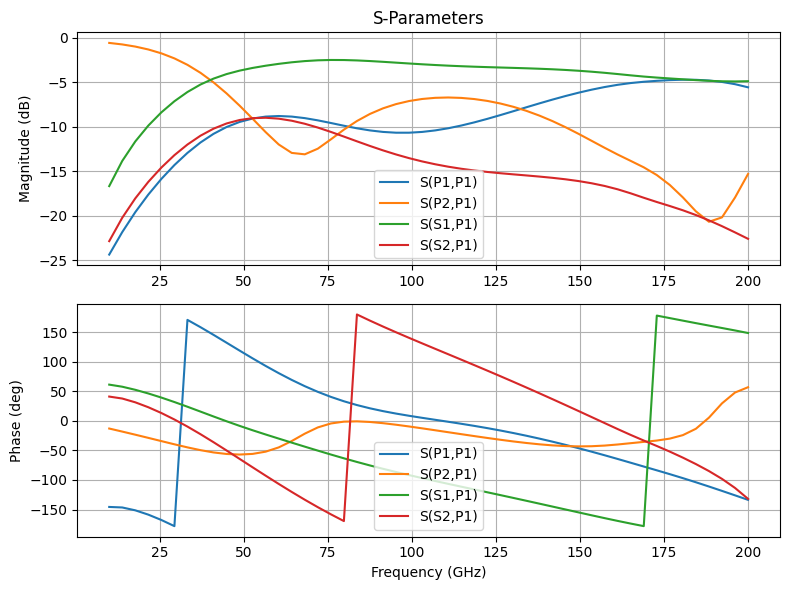

In [12]:
results.plot()

### Mixed-Mode S-Parameter Conversion

This section converts the raw 4-port single-ended simulation data into 2-port differential metrics to evaluate transformer performance.

* **Data Restructuring**: Compiles the complex single-ended data into a 3D NumPy array of shape `(frequencies, ports, ports)`.
* **Network Transformation**: Instantiates a `scikit-rf.Network` and applies `.se2gmm(p=2)` to mathematically convert single-ended ports into differential pairs.
* **Key Metrics Plotted**:
  * **`S11_diff` (Primary Return Loss)**: Impedance match at the input.
  * **`S22_diff` (Secondary Return Loss)**: Impedance match at the output.
  * **`S21_diff` (Insertion Loss)**: Magnetic power transfer efficiency across the transformer gap.

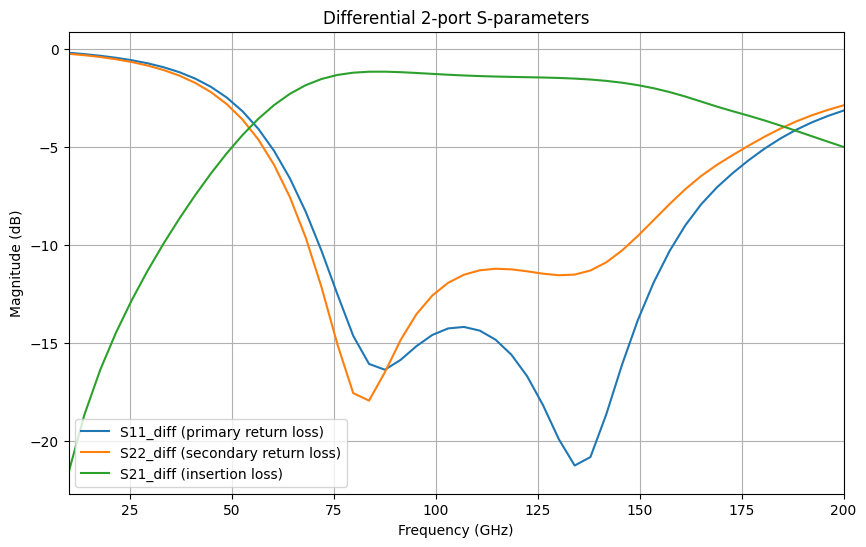

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import skrf as rf

f = results.freq

ports = results.port_names
n = len(ports)

S = np.zeros((len(f), n, n), dtype=complex)
for i, pi in enumerate(ports):
    for j, pj in enumerate(ports):
        S[:, i, j] = results[(pi, pj)].complex

ntwk = rf.Network(f=f, s=S, f_unit="ghz")
ntwk_mixed = ntwk.copy()
ntwk_mixed.se2gmm(p=2)

plt.figure(figsize=(10, 6))
ntwk_mixed.s11.plot_s_db(label="S11_diff (primary return loss)")
ntwk_mixed.s22.plot_s_db(label="S22_diff (secondary return loss)")
ntwk_mixed.s21.plot_s_db(label="S21_diff (insertion loss)")
plt.grid()
plt.title("Differential 2-port S-parameters")
plt.show()

Detected 4 ports: ['P1', 'P2', 'S1', 'S2']


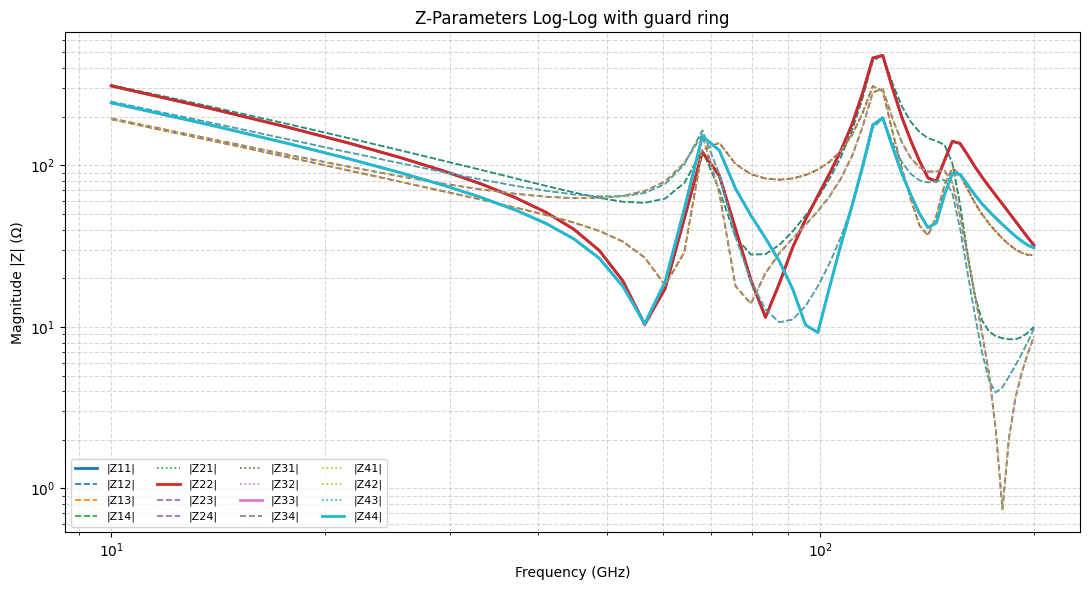

In [14]:
from s_to_z_parameters import plot_z_parameters

Z, Y, f = plot_z_parameters(results, freq_unit="GHz", title_suffix="with guard ring")

In [15]:
def _plot_transformer_diff(Z, f, f_plot, w, freq_unit, title_suffix):
    """
    Differential Z analysis for a 4-port transformer.
    Convention: ports 0,1 → primary winding; ports 2,3 → secondary winding.
    """
    # Primary differential impedance (port 1 vs port 2)
    Z_diff_pri = Z[:, 0, 0] + Z[:, 1, 1] - Z[:, 0, 1] - Z[:, 1, 0]
    # Secondary differential impedance (port 3 vs port 4)
    Z_diff_sec = Z[:, 2, 2] + Z[:, 3, 3] - Z[:, 2, 3] - Z[:, 3, 2]
    # Trans-impedance (primary → secondary coupling)
    Z_trans = Z[:, 0, 2] - Z[:, 0, 3] - Z[:, 1, 2] + Z[:, 1, 3]

    pairs = [
        (Z_diff_pri, "Z_diff Primary (1-2)", "royalblue"),
        (Z_diff_sec, "Z_diff Secondary (3-4)", "crimson"),
        (Z_trans, "Z_trans (coupling 1→3)", "seagreen"),
    ]

    # ── Magnitude plot ────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 6))
    for Z_d, lbl, col in pairs:
        ax.plot(f_plot, np.abs(Z_d), label=f"|{lbl}|", color=col, lw=2.5)
        ax.plot(
            f_plot,
            np.abs(np.real(Z_d)),
            label=f"|Re{{{lbl}}}|",
            color=col,
            lw=1.5,
            ls="--",
            alpha=0.7,
        )
        ax.plot(
            f_plot,
            np.abs(np.imag(Z_d)),
            label=f"|Im{{{lbl}}}|",
            color=col,
            lw=1.5,
            ls=":",
            alpha=0.7,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(f"Frequency ({freq_unit})")
    ax.set_ylabel("Magnitude |Z| (Ω)")
    ax.set_title(f"Differential Z-Parameters (Log-Log) {title_suffix}")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    # ── Inductance & Q per winding ────────────────────────────────────────────
    print("\n── Transformer Extracted Parameters ──────────────────────────")
    for Z_d, lbl in [(Z_diff_pri, "Primary"), (Z_diff_sec, "Secondary")]:
        L = np.imag(Z_d) / w
        Q = np.imag(Z_d) / np.real(Z_d)
        mask = L > 0
        if mask.sum() == 0:
            print(f"{lbl}: no positive inductance found")
            continue
        f_mask = f[mask]
        idx_1g = np.argmin(np.abs(f_mask - 1e9))
        idx_Q = np.argmax(Q[mask])
        print(f"  {lbl}:")
        print(f"    L  @ 1 GHz  = {L[mask][idx_1g] * 1e12:.1f} pH")
        print(
            f"    Peak Q      = {Q[mask][idx_Q]:.1f}  @ {f_mask[idx_Q] / 1e9:.2f} GHz"
        )
        print(f"    R_s @ 1 GHz = {np.real(Z_d[mask][idx_1g]):.3f} Ω")

    # ── Coupling coefficient k ────────────────────────────────────────────────
    L_pri = np.imag(Z_diff_pri) / w
    L_sec = np.imag(Z_diff_sec) / w
    M = np.imag(Z_trans) / w
    denom = np.sqrt(np.abs(L_pri * L_sec))
    with np.errstate(divide="ignore", invalid="ignore"):
        k = np.where(denom > 0, M / denom, np.nan)
    valid = np.isfinite(k) & (L_pri > 0) & (L_sec > 0)
    if valid.sum():
        idx_1g = np.argmin(np.abs(f[valid] - 1e9))
        print(f"  Coupling k  @ 1 GHz  = {k[valid][idx_1g]:.3f}")
        print(
            f"  Coupling k  range     = [{np.nanmin(k[valid]):.3f}, {np.nanmax(k[valid]):.3f}]"
        )
    print("──────────────────────────────────────────────────────────────")